# Notebook 04 — Assessment Performance & Outcome Prediction

**Project:** Programme Health Intelligence: A Learning Analytics Case Study  
**Dataset:** Open University Learning Analytics Dataset (OULAD)  
**Author:** Megha Sinha  
**Date:** June 2026

---

## Objective

This notebook examines how assessment performance relates to final
outcomes, addressing Business Question 4:

*"How strongly do early assessment scores predict final results? What
score thresholds are associated with pass vs fail vs withdrawal outcomes?
Does submission timing correlate with outcomes?"*

### What We Will Cover
1. Load and prepare assessment and student data
2. Analyse overall score distribution by final outcome
3. Identify score thresholds associated with each outcome
4. Examine submission timing vs final outcome
5. Determine how early assessment data becomes predictive
6. Combine assessment and engagement signals as early warning indicators

---

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Global Style Settings ──────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'axes.labelsize':     11,
    'axes.labelcolor':    '#2C2C2C',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         130,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight'
})

sns.set_theme(style='whitegrid', rc={
    'grid.color':     '#E5E5E5',
    'grid.linewidth': 0.7
})

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Business Colour Palette ────────────────────────────────────────
outcome_colours = {
    'Pass':        '#2C5F8A',
    'Distinction': '#1A3A5C',
    'Fail':        '#C0392B',
    'Withdrawn':   '#7F8C8D'
}

def add_bar_labels(ax, fmt='{:.0f}', padding=2,
                   fontsize=10, color='#2C2C2C'):
    for bar in ax.patches:
        val = bar.get_height()
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                val + padding,
                fmt.format(val),
                ha='center', va='bottom',
                fontsize=fontsize, color=color,
                fontweight='bold'
            )

print("Global styles and palette loaded successfully")

Global styles and palette loaded successfully


---

## 2. Load Cleaned Data

In [2]:
processed_path = '../data/processed/'

student_assessment = pd.read_csv(processed_path + 'studentAssessment_clean.csv')
assessments        = pd.read_csv(processed_path + 'assessments_clean.csv')
student_info       = pd.read_csv(processed_path + 'studentInfo_clean.csv')

print("Files loaded successfully\n")
print(f"  student_assessment: {student_assessment.shape[0]:,} rows")
print(f"  assessments:        {assessments.shape[0]:,} rows")
print(f"  student_info:       {student_info.shape[0]:,} rows")

Files loaded successfully

  student_assessment: 173,739 rows
  assessments:        206 rows
  student_info:       32,593 rows


---

## 3. Prepare Assessment Data

Merging assessment scores with module context and final outcomes
to enable score and timing analysis across outcome groups.

In [3]:
# Merge student_assessment with assessment metadata
assessment_full = student_assessment.merge(
    assessments[['id_assessment', 'code_module',
                 'code_presentation', 'assessment_type',
                 'date', 'weight']],
    on='id_assessment',
    how='left'
)

# Merge with final outcomes
assessment_full = assessment_full.merge(
    student_info[['id_student', 'code_module',
                  'code_presentation', 'final_result']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='inner'
)

# Submission timing — days early/late relative to deadline
# Negative = submitted before deadline, Positive = submitted after
assessment_full['days_to_deadline'] = (
    assessment_full['date_submitted'] - assessment_full['date']
)

# Classify submission timing
assessment_full['submission_timing'] = pd.cut(
    assessment_full['days_to_deadline'],
    bins=[-float('inf'), -7, 0, 7, float('inf')],
    labels=['Early (>7 days before)',
            'On Time (0-7 days before)',
            'Late (0-7 days after)',
            'Very Late (>7 days after)']
)

print("=== ASSESSMENT DATA — SUMMARY ===\n")
print(f"Total assessment records:  {len(assessment_full):,}")
print(f"Unique students:           {assessment_full['id_student'].nunique():,}")
print(f"Assessment types:          {assessment_full['assessment_type'].unique()}")
print(f"Score range:               {assessment_full['score'].min():.0f} — {assessment_full['score'].max():.0f}")
print(f"\nSubmission timing distribution:")
print(assessment_full['submission_timing'].value_counts().sort_index())

=== ASSESSMENT DATA — SUMMARY ===

Total assessment records:  173,739
Unique students:           23,351
Assessment types:          ['TMA' 'CMA' 'Exam']
Score range:               0 — 100

Submission timing distribution:
Early (>7 days before)       42553
On Time (0-7 days before)    79137
Late (0-7 days after)        43383
Very Late (>7 days after)     5801
Name: submission_timing, dtype: int64


---

## 4. Score Distribution by Final Outcome

Examining how assessment scores differ across outcome groups —
and identifying score thresholds associated with each outcome.

In [6]:
# Score summary by final outcome
score_by_outcome = (
    assessment_full
    .groupby('final_result')['score']
    .describe()
    .round(1)
    .reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn'])
)

print("=== SCORE DISTRIBUTION BY FINAL OUTCOME ===\n")
print(score_by_outcome)

# Median score by outcome
print("\nMedian score by outcome:")
median_scores = (
    assessment_full
    .groupby('final_result')['score']
    .median()
    .reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn'])
    .round(1)
)
print(median_scores)

=== SCORE DISTRIBUTION BY FINAL OUTCOME ===

                 count  mean   std  min   25%   50%   75%    max
final_result                                                    
Distinction   26330.00 88.70 11.40 0.00 83.00 91.00 97.00 100.00
Pass         105987.00 76.80 16.50 0.00 68.00 79.00 88.00 100.00
Fail          28399.00 64.70 21.40 0.00 52.00 66.00 80.00 100.00
Withdrawn     13023.00 66.10 23.20 0.00 53.00 70.00 83.00 100.00

Median score by outcome:
final_result
Distinction   91.00
Pass          79.00
Fail          66.00
Withdrawn     70.00
Name: score, dtype: float64


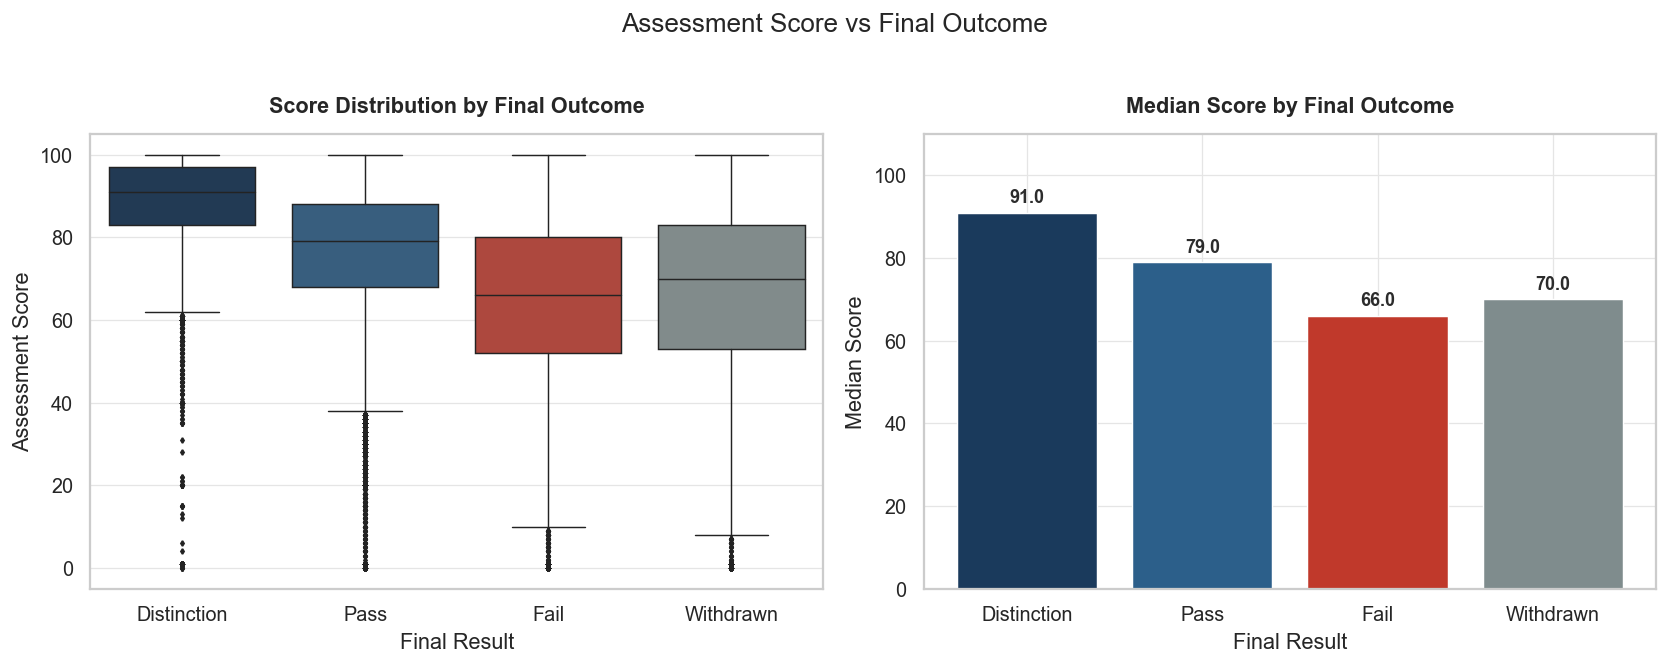

Chart saved to images/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

outcome_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

# Left — box plot of scores by outcome
sns.boxplot(
    data=assessment_full,
    x='final_result',
    y='score',
    order=outcome_order,
    palette=outcome_colours,
    ax=axes[0],
    linewidth=0.8,
    fliersize=2
)
axes[0].set_title('Score Distribution by Final Outcome')
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Assessment Score')

# Right — median score bar chart
colours_list = [outcome_colours[o] for o in outcome_order]
bars = axes[1].bar(
    median_scores.index,
    median_scores.values,
    color=colours_list,
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_title('Median Score by Final Outcome')
axes[1].set_xlabel('Final Result')
axes[1].set_ylabel('Median Score')
axes[1].set_ylim(0, 110)
add_bar_labels(axes[1], fmt='{:.1f}', padding=1.5)

fig.suptitle('Assessment Score vs Final Outcome', y=1.02)
plt.tight_layout()
plt.savefig('../images/09_score_by_outcome.png')
plt.show()
print("Chart saved to images/")

---

## 5. Score Thresholds by Outcome

Identifying the score ranges most strongly associated with each
outcome — giving operations teams a data-driven threshold for
flagging at-risk students based on assessment performance alone.

In [8]:
# Define score bands
assessment_full['score_band'] = pd.cut(
    assessment_full['score'],
    bins=[0, 40, 55, 70, 85, 100],
    labels=['Very Low (0-40)', 'Low (41-55)',
            'Medium (56-70)', 'High (71-85)',
            'Very High (86-100)'],
    include_lowest=True
)

# Outcome distribution within each score band
score_band_outcomes = (
    assessment_full
    .groupby(['score_band', 'final_result'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
             fill_value=0)
)

score_band_outcomes['total'] = score_band_outcomes.sum(axis=1)
score_band_outcomes['success_rate'] = (
    (score_band_outcomes['Distinction'] +
     score_band_outcomes['Pass']) /
    score_band_outcomes['total'] * 100
).round(1)
score_band_outcomes['fail_withdrawn_rate'] = (
    (score_band_outcomes['Fail'] +
     score_band_outcomes['Withdrawn']) /
    score_band_outcomes['total'] * 100
).round(1)

print("=== OUTCOME RATES BY SCORE BAND ===\n")
print(score_band_outcomes)

=== OUTCOME RATES BY SCORE BAND ===

final_result        Distinction   Pass  Fail  Withdrawn  total  success_rate  \
score_band                                                                     
Very Low (0-40)             179   3306  4129       1930   9544         36.50   
Low (41-55)                 135   6572  4402       1664  12773         52.50   
Medium (56-70)             1239  22707  7967       3196  35109         68.20   
High (71-85)               6749  41020  7518       3582  58869         81.10   
Very High (86-100)        18028  32382  4383       2651  57444         87.80   

final_result        fail_withdrawn_rate  
score_band                               
Very Low (0-40)                   63.50  
Low (41-55)                       47.50  
Medium (56-70)                    31.80  
High (71-85)                      18.90  
Very High (86-100)                12.20  


---

### 5.1 Score Band Outcomes — Visualisation

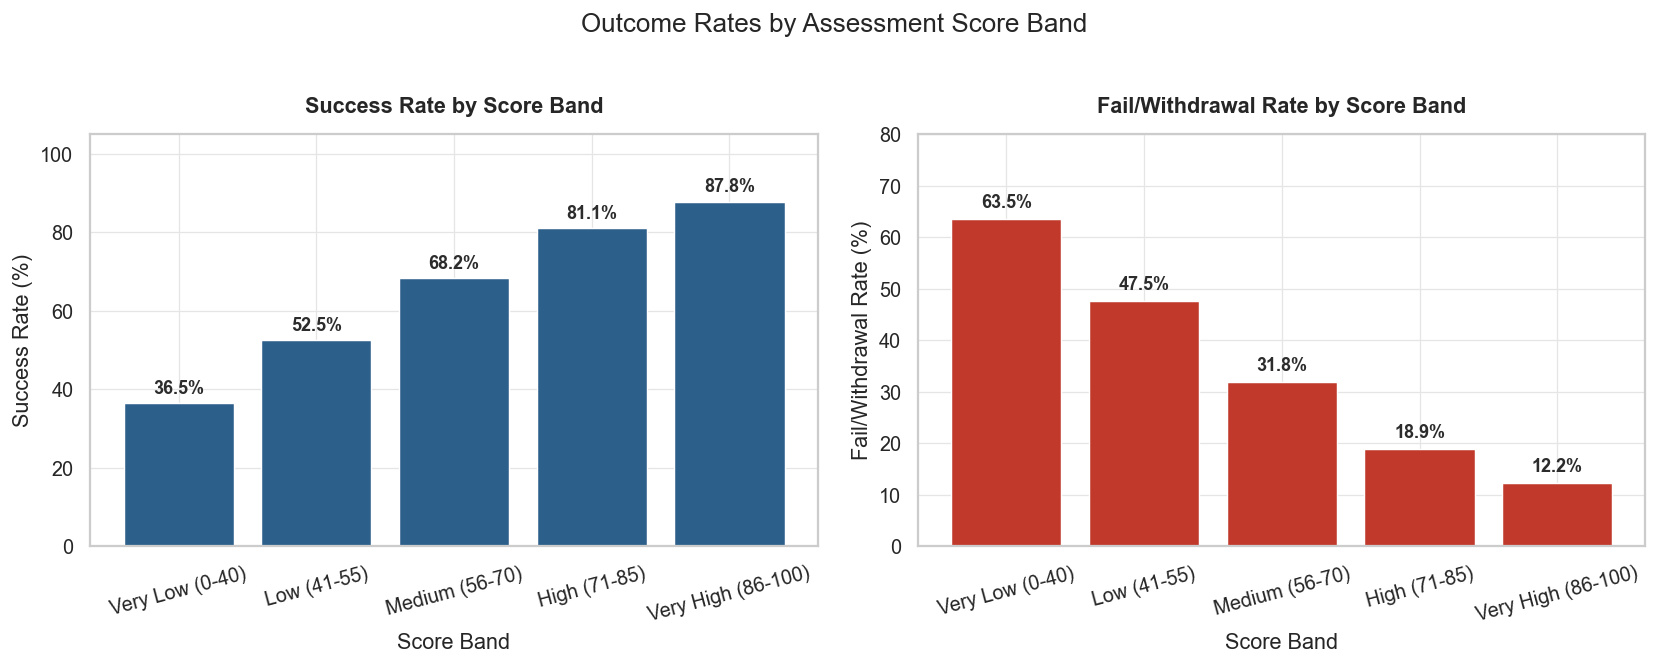

Chart saved to images/


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

band_labels = score_band_outcomes.index.tolist()

# Left — success rate by score band
axes[0].bar(band_labels,
            score_band_outcomes['success_rate'],
            color='#2C5F8A', edgecolor='white', linewidth=0.8)
axes[0].set_title('Success Rate by Score Band')
axes[0].set_xlabel('Score Band')
axes[0].set_ylabel('Success Rate (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=15)
add_bar_labels(axes[0], fmt='{:.1f}%', padding=1.5)

# Right — fail/withdrawn rate by score band
axes[1].bar(band_labels,
            score_band_outcomes['fail_withdrawn_rate'],
            color='#C0392B', edgecolor='white', linewidth=0.8)
axes[1].set_title('Fail/Withdrawal Rate by Score Band')
axes[1].set_xlabel('Score Band')
axes[1].set_ylabel('Fail/Withdrawal Rate (%)')
axes[1].set_ylim(0, 80)
axes[1].tick_params(axis='x', rotation=15)
add_bar_labels(axes[1], fmt='{:.1f}%', padding=1.5)

fig.suptitle('Outcome Rates by Assessment Score Band', y=1.02)
plt.tight_layout()
plt.savefig('../images/10_score_bands.png')
plt.show()
print("Chart saved to images/")

---

## 6. Submission Timing vs Final Outcome

Does submitting assessments early, on time, or late correlate
with final outcomes — and how strong is that signal?

In [10]:
# Outcome distribution by submission timing
timing_outcomes = (
    assessment_full
    .groupby(['submission_timing', 'final_result'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Distinction', 'Pass', 'Fail', 'Withdrawn'],
             fill_value=0)
)

timing_outcomes['total'] = timing_outcomes.sum(axis=1)
timing_outcomes['success_rate'] = (
    (timing_outcomes['Distinction'] + timing_outcomes['Pass']) /
    timing_outcomes['total'] * 100
).round(1)
timing_outcomes['fail_withdrawn_rate'] = (
    (timing_outcomes['Fail'] + timing_outcomes['Withdrawn']) /
    timing_outcomes['total'] * 100
).round(1)

print("=== OUTCOME RATES BY SUBMISSION TIMING ===\n")
print(timing_outcomes[['total', 'success_rate', 'fail_withdrawn_rate']])

# Median score by submission timing
print("\nMedian score by submission timing:")
print(
    assessment_full
    .groupby('submission_timing')['score']
    .median()
    .round(1)
)

=== OUTCOME RATES BY SUBMISSION TIMING ===

final_result               total  success_rate  fail_withdrawn_rate
submission_timing                                                  
Early (>7 days before)     42553         84.20                15.80
On Time (0-7 days before)  79137         76.70                23.30
Late (0-7 days after)      43383         69.40                30.60
Very Late (>7 days after)   5801         55.10                44.90

Median score by submission timing:
submission_timing
Early (>7 days before)      82.00
On Time (0-7 days before)   77.00
Late (0-7 days after)       80.00
Very Late (>7 days after)   65.00
Name: score, dtype: float64


---

## 7. How Early Does Assessment Data Become Predictive?

A critical operational question — how many weeks into a module
before assessment scores reliably signal final outcomes?
The earlier the signal, the more time there is to intervene.

In [11]:
# Merge assessment data with module context
assessment_timing = assessment_full.merge(
    assessments[['id_assessment', 'date']].rename(
        columns={'date': 'assessment_date'}),
    on='id_assessment',
    how='left'
)

# Convert assessment date to week
assessment_timing['assessment_week'] = (
    assessment_timing['assessment_date'] // 7
).astype('Int64')

# For each week — calculate success rate of students
# who scored above/below 55 threshold
weekly_prediction = (
    assessment_timing[assessment_timing['assessment_week'].notna()]
    .groupby('assessment_week')
    .apply(lambda x: pd.Series({
        'total_submissions': len(x),
        'above_threshold': (x['score'] >= 55).sum(),
        'success_rate_above': x[x['score'] >= 55]['final_result']
        .isin(['Pass', 'Distinction']).mean() * 100,
        'success_rate_below': x[x['score'] < 55]['final_result']
        .isin(['Pass', 'Distinction']).mean() * 100
    }))
    .reset_index()
    .round(1)
)

# Focus on first 20 weeks
weekly_prediction = weekly_prediction[
    weekly_prediction['assessment_week'] <= 20]

print("=== PREDICTIVE POWER BY ASSESSMENT WEEK ===\n")
print(weekly_prediction[['assessment_week', 'total_submissions',
                          'success_rate_above',
                          'success_rate_below']].to_string(index=False))

=== PREDICTIVE POWER BY ASSESSMENT WEEK ===

 assessment_week  total_submissions  success_rate_above  success_rate_below
               1            1188.00               63.70               30.30
               2           13398.00               63.10               35.00
               3            7428.00               60.00               17.90
               4            4646.00               69.50               10.50
               5            2406.00               65.50               26.10
               6            6681.00               70.50               30.80
               7           11453.00               70.00               29.40
               8            3268.00               72.90               42.60
               9            4597.00               76.00               22.50
              10             711.00               73.70               21.10
              11            3528.00               73.70               29.90
              12            5313.00        

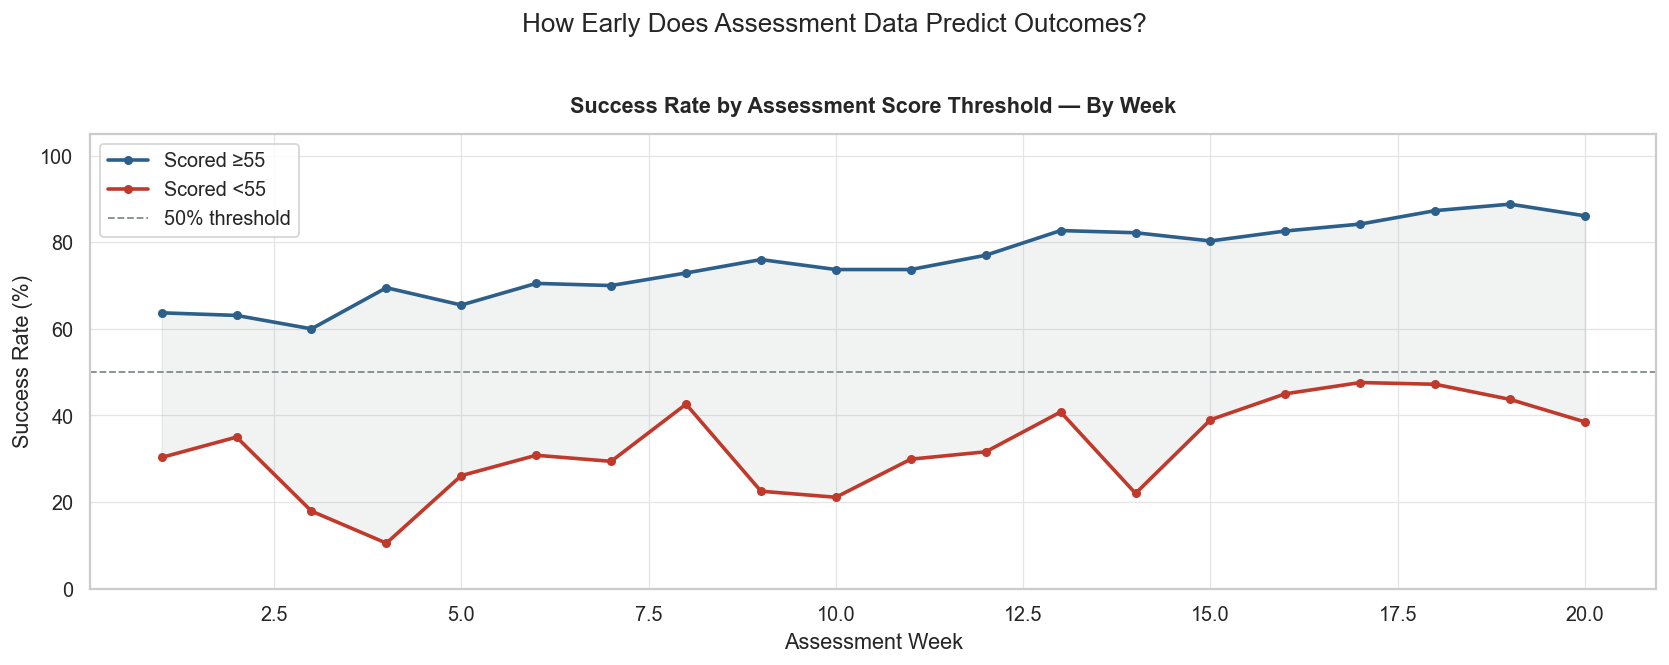

Chart saved to images/


In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(weekly_prediction['assessment_week'].astype(float),
        weekly_prediction['success_rate_above'],
        color='#2C5F8A', linewidth=2, marker='o',
        markersize=4, label='Scored ≥55')

ax.plot(weekly_prediction['assessment_week'].astype(float),
        weekly_prediction['success_rate_below'],
        color='#C0392B', linewidth=2, marker='o',
        markersize=4, label='Scored <55')

ax.fill_between(weekly_prediction['assessment_week'].astype(float),
                weekly_prediction['success_rate_above'].astype(float),
                weekly_prediction['success_rate_below'].astype(float),
                alpha=0.1, color='#7F8C8D')

ax.axhline(y=50, color='#7F8C8D', linestyle='--',
           linewidth=1, label='50% threshold')
ax.set_title('Success Rate by Assessment Score Threshold — By Week')
ax.set_xlabel('Assessment Week')
ax.set_ylabel('Success Rate (%)')
ax.set_ylim(0, 105)
ax.legend()

fig.suptitle('How Early Does Assessment Data Predict Outcomes?', y=1.02)
plt.tight_layout()
plt.savefig('../images/11_predictive_power_by_week.png')
plt.show()
print("Chart saved to images/")

In [ ]:
---

## 8. Notebook Summary

### Key Findings

| Finding | Detail |
|---|---|
| Score-outcome relationship | Clear and consistent — median rises from 66 (Fail) to 91 (Distinction) |
| Withdrawn vs Fail scores | Withdrawn median (70) higher than Fail (66) — withdrawal is engagement-driven not performance-driven |
| Critical score threshold | 55 marks — below this, fail/withdrawal rate exceeds 47.5% |
| Critical risk zone | Below 40 marks — 63.5% fail or withdraw |
| Submission timing | Independent risk signal — late submitters have higher fail/withdrawal rates even with similar scores |
| Very late submission | 44.9% fail/withdrawal rate — strongest behavioural warning signal |
| Early predictability | Assessment data becomes reliably predictive from week 4 onwards |

### Operational Recommendations

1. **Flag students scoring below 55** for immediate academic support
2. **Treat scores below 40 as critical** — 63.5% fail/withdrawal rate warrants urgent intervention
3. **Monitor submission timing independently of score** — late submission is a standalone risk signal
4. **Act on very late submissions immediately** — 44.9% fail/withdrawal rate
5. **Use week 4 assessment data** as the earliest reliable predictor for at-risk identification

### Files Produced

| File | Location |
|---|---|
| 09_score_by_outcome.png | images/ |
| 10_score_bands.png | images/ |
| 11_predictive_power_by_week.png | images/ |

### Next Steps
**Notebook 05 — At-Risk Identification:** Combining engagement,
assessment, and submission timing signals into a unified at-risk
framework — identifying which students need intervention and when.